## Convert data with `pygid`

In [89]:
import pygid

exp_metadata = pygid.ExpMetadata(
    start_time = r"2025-09-09T20:36:23.076828",
    end_time = r"2025-09-09T20:37:24.076828",
    source_type = "synchrotron",
    source_name = "ESRF ID10",
    detector = "eiger4m",
    monitor = 294302)

smpl_metadata = pygid.SampleMetadata(path_to_load="sample.yaml")

INFO - Saved in D:\PhD\mlgid\mlgidBASE\example\result_from_file.h5 in group entry_0000


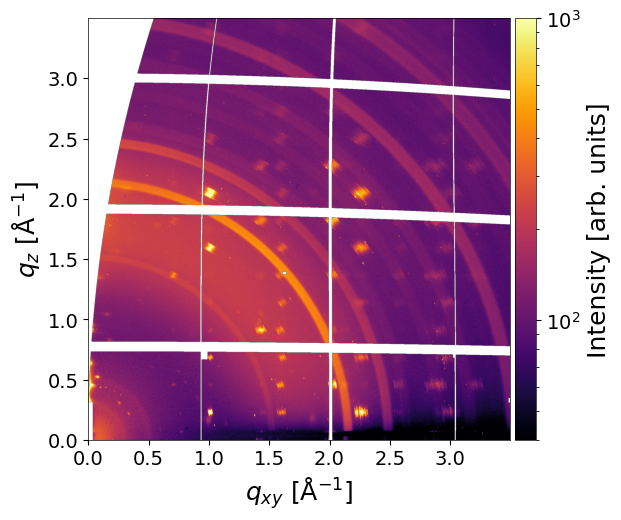

In [90]:

poni_path = './laB6_2025_09_05.poni'
mask_path = './mask.npy'
filename = './eiger4m_0000.h5'
dataset = '/entry/data0/image'
frame_num = 0

params = pygid.ExpParams(
	poni_path = poni_path,
    mask_path = mask_path,
    fliplr = True,
    flipud = True,
    # transp = False,
    ai = 0.075
)

matrix = pygid.CoordMaps(
    params,
    vert_positive = True, hor_positive = True,
    q_xy_range = (0, 3.5), q_z_range = (0, 3.5), dq = 0.002,
)

conversion = pygid.Conversion(
    matrix = matrix,
    path = filename,
    dataset = dataset,
    frame_num = frame_num
)

conversion.det2q_gid(clims = (40, 1000),
    plot_result = True, return_result = False,
    save_result = True, path_to_save = "result_from_file.h5",
    overwrite_file = True, h5_group = "entry_0000",
    overwrite_group = False,
    # smpl_metadata = smpl_metadata, exp_metadata=exp_metadata
)


## From `pygid.Conversion`

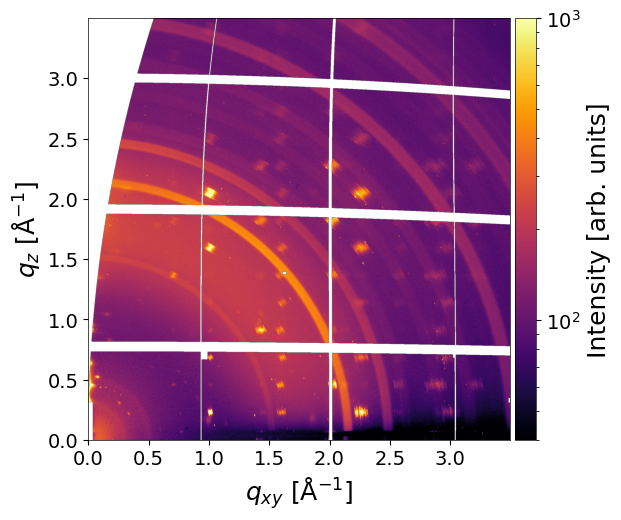

In [77]:
conversion.det2q_gid(clims = (40, 1000),
    plot_result = True, return_result = False,
    save_result = False)

In [78]:
from mlgidbase import mlgidBASE
analysis = mlgidBASE(pygid_conversion = conversion)

In [79]:
analysis.run_detection()

INFO - Loading model


In [80]:
analysis.run_fitting()

In [81]:
analysis.run_matching(cif_prepr = r'prepr_cifs.pickle', peaks_type='segments', threshold=0.01)

In [82]:
analysis.save_result(path_to_save='result_from_conversion.h5', smpl_metadata = smpl_metadata, exp_metadata=exp_metadata)

INFO - Saved in D:\PhD\mlgid\mlgidBASE\example\result_from_conversion.h5 in group entry_0000


## From file

In [83]:
import numpy as np
from mlgidbase import mlgidBASE

In [84]:
filename = r'result_from_file.h5'
analysis = mlgidBASE(filename = filename)

In [85]:
analysis.run_detection()

INFO - Loading model
INFO - Saved detected peaks to file: result_from_file.h5, entry: entry_0000, frame: 0


In [86]:
analysis.run_fitting()

INFO - Saved fitted peaks to file: result_from_file.h5, entry: entry_0000, frame: 0


In [87]:
analysis.run_matching(cif_prepr = r'prepr_cifs.pickle', peaks_type='rings', threshold=0.01)

INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 0


In [88]:
analysis.run_matching(cif_prepr = r'prepr_cifs.pickle', peaks_type='segments', threshold=0.1)

INFO - cif_prepr is already set. The previous cif_prepr is to be used
INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 0
